In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load Dataset

In [2]:
df = pd.read_csv("/content/sample_data/archive (10).zip")
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


# Check Dataset Information

In [3]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
(1338, 7)


# Check Missing Values

In [4]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


# Remove Duplicate Records

In [5]:
df.drop_duplicates(inplace=True)
print(df.shape)

(1337, 7)


# Descriptive Statistics

In [6]:
print("Average Age:", df["age"].mean())
print("Average BMI:", df["bmi"].mean())
print("Average Children:",
      df["children"].mean())
print("Average Charges:",
      df["charges"].mean())
print(df.describe())

Average Age: 39.222139117427076
Average BMI: 30.66345175766642
Average Children: 1.0957367240089753
Average Charges: 13279.121486655948
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


# Encode Categorical Variables

In [7]:
le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

# Insurance Cost Analysis

In [9]:
print(
df.groupby("smoker")["charges"].mean()
)
print(
df.groupby("sex")["charges"].mean()
)
print(
df.groupby("region")["charges"].mean()
)

smoker
0     8440.660307
1    32050.231832
Name: charges, dtype: float64
sex
0    12569.578844
1    13974.998864
Name: charges, dtype: float64
region
0    13406.384516
1    12450.840844
2    14735.411438
3    12346.937377
Name: charges, dtype: float64


# Relationship Analysis

In [10]:
print(
df[["age","charges"]].corr()
)
print(
df[["children","charges"]].corr()
)
print(
df[["children","charges"]].corr()
)

              age   charges
age      1.000000  0.298308
charges  0.298308  1.000000
          children   charges
children  1.000000  0.067389
charges   0.067389  1.000000
          children   charges
children  1.000000  0.067389
charges   0.067389  1.000000


# Simple Linear Regression

In [11]:
X = df[["age"]]
y = df["charges"]
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)
lr = LinearRegression()

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("R2 Score:",
r2_score(y_test,y_pred))

print("MAE:",
mean_absolute_error(y_test,y_pred))

print("MSE:",
mean_squared_error(y_test,y_pred))

print("RMSE:",
np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score: 0.09513000782072023
MAE: 9657.78934976123
MSE: 166275348.23176482
RMSE: 12894.779883028823


# Multiple Linear Regression

In [12]:
X = df[
[
"age",
"bmi",
"children",
"smoker"
]
]
y = df["charges"]
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)
mlr = LinearRegression()
mlr.fit(X_train,y_train)
y_pred = mlr.predict(X_test)
print("R2 Score:",
r2_score(y_test,y_pred))
print("MAE:",
mean_absolute_error(y_test,y_pred))
print("MSE:",
mean_squared_error(y_test,y_pred))
print("RMSE:",
np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score: 0.8045531086669288
MAE: 4198.592612356366
MSE: 35914551.48043363
RMSE: 5992.875059638206


# Create Insurance Category

In [15]:
median_charge = df["charges"].median()
df["insurance_category"] = (
df["charges"] > median_charge
).astype(int)


# Logistic Regression

In [16]:
X = df[
[
"age",
"bmi",
"children",
"smoker"
]
]
y = df["insurance_category"]
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)
log_model = LogisticRegression(
max_iter=1000
)

log_model.fit(
X_train,
y_train
)
y_pred = log_model.predict(X_test)
print("Accuracy:",
accuracy_score(y_test,y_pred))

print(confusion_matrix(
y_test,
y_pred
))

print(classification_report(
y_test,
y_pred
))

Accuracy: 0.9067164179104478
[[117  15]
 [ 10 126]]
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       132
           1       0.89      0.93      0.91       136

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



# Data Visualization

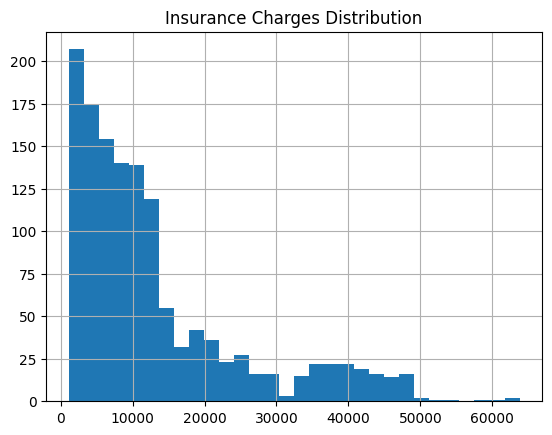

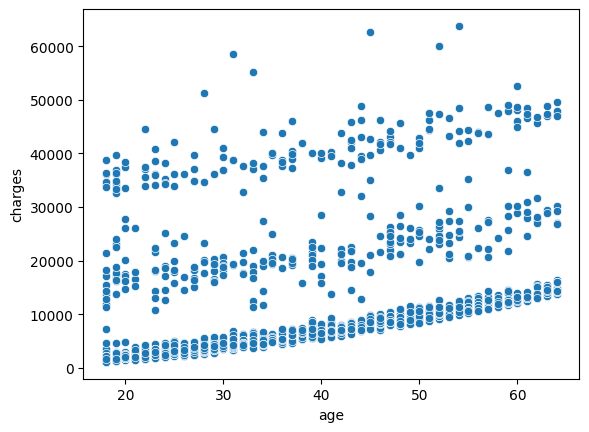

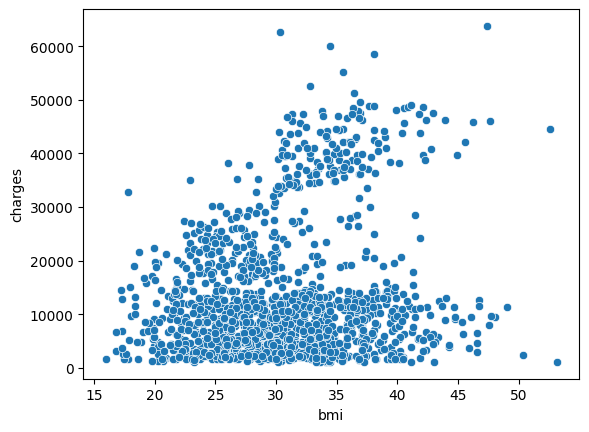

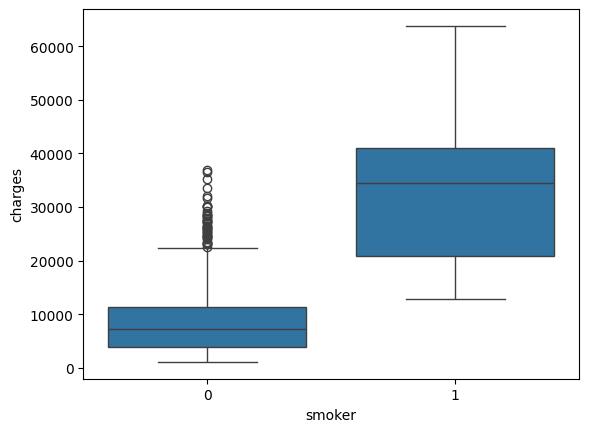

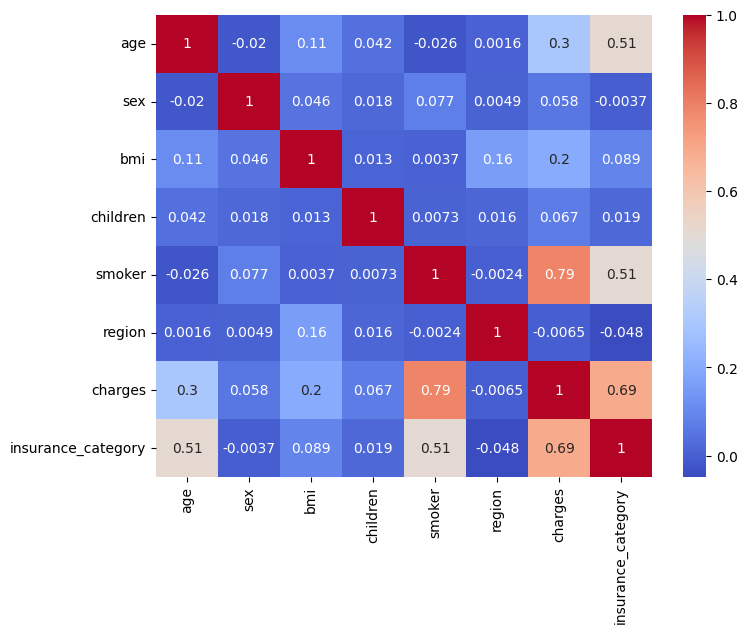

In [17]:
import matplotlib.pyplot as plt
df["charges"].hist(bins=30)
plt.title(
"Insurance Charges Distribution"
)
plt.show()
import seaborn as sns
sns.scatterplot(
x="age",
y="charges",
data=df
)
plt.show()
sns.scatterplot(
x="bmi",
y="charges",
data=df
)
plt.show()
sns.boxplot(
x="smoker",
y="charges",
data=df
)
plt.show()
plt.figure(figsize=(8,6))

sns.heatmap(
df.corr(),
annot=True,
cmap="coolwarm"
)
plt.show()

# Risk Analysis

In [18]:
high_cost = df[
df["insurance_category"] == 1
]
print(high_cost.head())
low_cost = df[
df["insurance_category"] == 0
]
print(low_cost.head())

    age  sex     bmi  children  smoker  region      charges  \
0    19    0  27.900         0       1       3  16884.92400   
3    33    1  22.705         0       0       1  21984.47061   
9    60    0  25.840         0       0       1  28923.13692   
11   62    0  26.290         0       1       2  27808.72510   
13   56    0  39.820         0       0       2  11090.71780   

    insurance_category  
0                    1  
3                    1  
9                    1  
11                   1  
13                   1  
   age  sex    bmi  children  smoker  region    charges  insurance_category
1   18    1  33.77         1       0       2  1725.5523                   0
2   28    1  33.00         3       0       2  4449.4620                   0
4   32    1  28.88         0       0       1  3866.8552                   0
5   31    0  25.74         0       0       2  3756.6216                   0
6   46    0  33.44         1       0       2  8240.5896                   0


# Dashboard Creation Using Plotly

In [19]:
import plotly.express as px
fig = px.histogram(
df,
x="charges",
title="Insurance Charges Distribution"
)
fig.show()
fig = px.scatter(
df,
x="age",
y="charges",
color="smoker",
title="Age vs Charges"
)
fig.show()
fig = px.box(
df,
x="region",
y="charges",
color="region",
title="Region Wise Charges"
)
fig.show()

# Conclusion

In [20]:
print("Medical Insurance Cost Analysis and Prediction System Completed Successfully")

Medical Insurance Cost Analysis and Prediction System Completed Successfully
